## Libraries

In [1]:
import os

In [2]:
run = 'local' #local or cloud
os.environ["APP_ENV"] = run

In [3]:
import sys
sys.path.append('..')

In [4]:
from src.grass_functions import*
from src.process_inputs import*
%matplotlib inline
#%load_ext autoreload
#%autoreload 2

C:\Program Files\GRASS GIS 7.8\etc\python\grass\script\db.py:147: SyntaxWarning: invalid escape sequence '\g'
  :param str args:  see \gmod{db.select} arguments
C:\Program Files\GRASS GIS 7.8\etc\python\grass\script\setup.py:30: SyntaxWarning: invalid escape sequence '\O'
  grass7bin = r'C:\OSGeo4W\bin\grass78.bat'
C:\Program Files\GRASS GIS 7.8\etc\python\grass\pygrass\modules\interface\parameter.py:141: SyntaxWarning: invalid escape sequence '\d'
  isrange = re.match("(?P<min>-*\d+.*\d*)*-(?P<max>\d+.*\d*)*",
C:\Program Files\GRASS GIS 7.8\etc\python\grass\pygrass\modules\interface\module.py:233: SyntaxWarning: invalid escape sequence '\_'
  To run the Module objects in parallel the run\_ and finish\_ options


# Parameters

In [5]:
#set project variables
Project_Area = 'haw_river_no_survey'
projection = '2264' #set to None if you want to use the DEM's original projection
res = '1m'

## Set variables analysis
source = 'user-defined' #wbd or user-defined
data_scale = 'name' #other options HUC12, HUC10, HUC8 OR the field name of the source data to be split <-- case sensitive
select_data = 'site' #     # Value within the filter_field used for data selection
to_headwaters = False #False if only interested in local huc area
input_shp_name = 'haw_aoi.shp' #None or must be populated populated with a shapefile polygons if data_scale != HUCXX
buffer = 2000
auto_delete = False

In [6]:
if data_scale.find('HUC') >= 0:
    huc_level = re.findall("[0-9]+",data_scale)[0]
    if huc_level == str(len(select_data)):
        huc_digys = huc_level
    else:
        huc_digys = huc_level
        select_data = select_data[:int(huc_digys)]

In [7]:
## Paths:
parent_dir = pl.Path(os.getcwd()).parent/'data'
current_dir = pl.Path(os.getcwd())
outputs_dir =parent_dir/'Rasters'/Project_Area/'Outputs'
vector_dir = parent_dir/'Vectors'/Project_Area
raster_dir = parent_dir/'Rasters'/Project_Area
huc_path = vector_dir/'{}_aoi.geojson'.format(Project_Area)
git_data_repo = current_dir/'data_repository'
if input_shp_name:
    input_shp = vector_dir/input_shp_name
directory = outputs_dir

### Get area of interest

In [8]:
#read from to vector path from notebook 1
huc_path = vector_dir/'{0}_{1}_aoi.geojson'.format(Project_Area,select_data)
aoi = gpd.read_file(str(huc_path),driver="GeoJSON")

c:\Users\Curtis.Smith\AppData\Local\miniforge3\envs\geoenv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: driver GeoJSON does not support open option DRIVER
  return ogr_read(


### Start new grass session

In [9]:
# define GRASS data settings (adapt to your needs)
location = Project_Area+'_'+projection
mapset = 'PERMANENT'

In [10]:
initialize_grass_db(location, mapset, projection)
#initialize_grass_db(Location, Mapset, GRASS_GIS_Projection)

Database Location Exists
Database Mapset Exists
None
{'GISDBASE': 'C:\\Users\\Curtis.Smith\\Documents\\grassdata', 'LOCATION_NAME': 'haw_river_no_survey_2264', 'MAPSET': 'PERMANENT'}


#### Review existing files

In [11]:
#list all grass files
grass_maps = list_existing_grass(print_it=True)

Available vector maps:
aoi@PERMANENT
aoi_buffer@PERMANENT

Available raster maps:
MASK@PERMANENT
dem_site@PERMANENT


In [12]:
basin_list = aoi[data_scale.lower()].to_list()
basins = 'aoi'
gs.run_command('v.import', input= huc_path,  output= basins)
print('added aoi to grass')

added aoi to grass


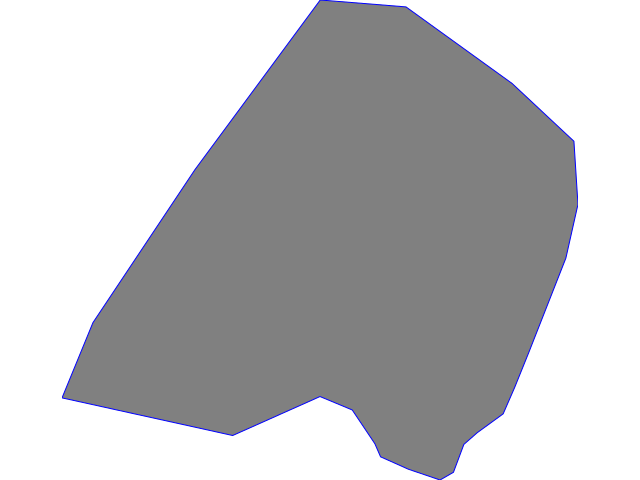

In [13]:
##print basins in grass @ Regional scale to confirm data and extent
gs.parse_command('g.region',vector = basins)
gs.run_command('d.erase')

#gs.run_command('d.vect', map='tmp_bsn_buffer',color='red',fill_color='gray')
gs.run_command('d.vect', map= basins,color='blue',fill_color='gray')

Image(filename="map.png")

In [14]:
#set variables
carved = False
carve_lines = vector_dir/'carve.shp'
outlet_point = vector_dir/f'{select_data}_outlet.shp'


In [15]:
#standard variables
threshold = 21760 #0.5 acre in feet
dem = 'dem_'+str(select_data)
c_lines = f'v_carve_{select_data}'
accum = f'accum_{select_data}'
drain_dir = f'drain_dir_{select_data}'
r_basins = f'r_basins_{select_data}'
v_basins = f'v_basins_{select_data}'
sub_basins = f'subbasins_{select_data}'
v_streams = f'stream_{select_data}'
r_streams = f'r_streams_{select_data}'
twi = f'r_twi_{select_data}'
v_outlet = f'outlet_{select_data}'

In [16]:
basins+'_buffer'

'aoi_buffer'

In [17]:
dem

'dem_site'

In [18]:
#add mask and reset region
gs.run_command('v.buffer',input=basins,output=basins+'_buffer',distance = buffer)
#mask outside cells
gs.run_command('g.region',vector = basins+'_buffer',align=dem)
gs.run_command('r.mask',vector = basins+'_buffer')

gs.run_command('g.region',raster = dem,align=dem,zoom=dem)
reg = gs.parse_command('g.region',raster = dem,align=dem,zoom=dem,flags='gp')

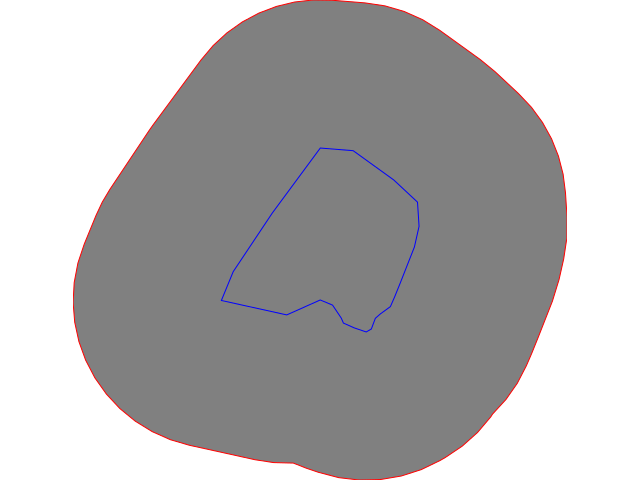

In [19]:
gs.run_command('d.erase')

gs.run_command('d.vect', map=basins+'_buffer',color='red',fill_color='gray')
gs.run_command('d.vect', map= basins,color='blue',fill_color='gray')

Image(filename="map.png")

In [20]:
cell_size = (float(reg.nsres)+ float(reg.ewres)) /2

In [21]:
grass_maps = list_existing_grass()

In [22]:
if carved and dem+'_b' not in grass_maps['raster']:
    gs.run_command('v.import', input= carve_lines,extent='region', output= c_lines)
    gs.run_command('r.carve',raster=dem,vector = c_lines, output= dem+'_b', flags='n', width = 2*cell_size,depth=0)
    dem+='_b'

In [23]:
gs.run_command('r.watershed', elevation=dem,threshold = threshold//(cell_size**2),accumulation=accum,basin=sub_basins,tci=twi,flags='sab')

0

In [24]:
gs.run_command('r.stream.extract',elevation=dem,threshold = threshold//(cell_size**2),accumulation=accum,direction=drain_dir,stream_raster=r_streams,stream_vector=v_streams)

0

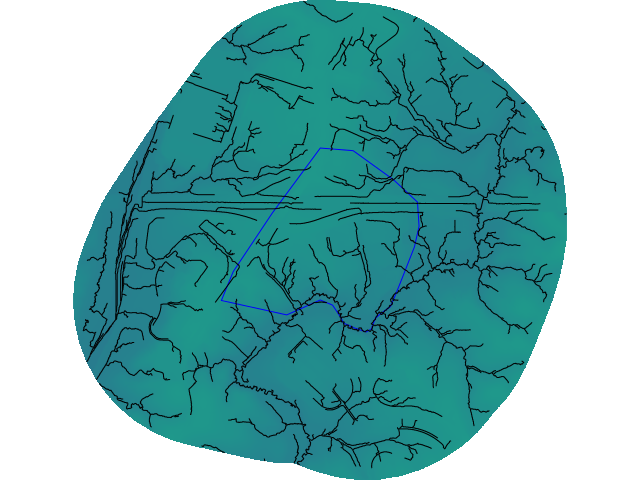

In [25]:
gs.run_command('d.erase')

gs.run_command('d.rast', map=dem)
gs.run_command('d.vect', map= basins,color='blue',fill_color='none')
gs.run_command('d.vect', map= v_streams,color='black',fill_color='none',type='line')

Image(filename="map.png")

In [26]:
## Export
gs.run_command('r.out.gdal', input= twi, output= raster_dir/f'{twi}.tif',createopt="BIGTIFF=YES,PROFILE=GeoTIFF,TFW=YES,COMPRESS=LZW",flags='f')
gs.run_command('r.out.gdal', input= dem, output= raster_dir/f'{dem}.tif',createopt="BIGTIFF=YES,PROFILE=GeoTIFF,TFW=YES,COMPRESS=LZW",flags='f')
gs.run_command('v.out.ogr',input=v_streams,output=vector_dir/f'{v_streams}.geojson',type= 'line',format='GeoJSON')

0

In [27]:
#convert to shp
#TODO add v.clean to code.
gpd.read_file(vector_dir/f'{v_streams}.geojson').to_file(vector_dir/f'{v_streams}.shp')

C:\Users\Curtis.Smith\AppData\Local\Temp\ipykernel_38068\4088301349.py:3: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gpd.read_file(vector_dir/f'{v_streams}.geojson').to_file(vector_dir/f'{v_streams}.shp')
c:\Users\Curtis.Smith\AppData\Local\miniforge3\envs\geoenv\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'stream_type' to 'stream_typ'
  ogr_write(
[2026-05-12 09:50:42,409] [INFO] [raw] : Created 817 records


## Watershed Delineation

In [28]:
#import outlet
gs.run_command('v.import', input= outlet_point,extent='region', output= v_outlet)

0

In [29]:
gs.run_command('r.stream.snap',input = v_outlet, output=f'{v_outlet}_snap',stream_rast = r_streams,radius = 10)

0

In [30]:
gs.run_command('r.stream.basins',points = f'{v_outlet}_snap', direction=drain_dir,basins=r_basins)

0

In [31]:
gs.run_command('r.to.vect',input = r_basins,output = v_basins, type='area',column='basin_col', flags='s')

0

In [32]:
gs.run_command('v.out.ogr',input=v_basins,output=vector_dir/f'{v_basins}.geojson',type= 'area',format='GeoJSON')
#convert to shp
gpd.read_file(vector_dir/f'{v_basins}.geojson').to_file(vector_dir/f'{v_basins}.shp')

[2026-05-12 09:52:57,565] [INFO] [raw] : Created 3 records


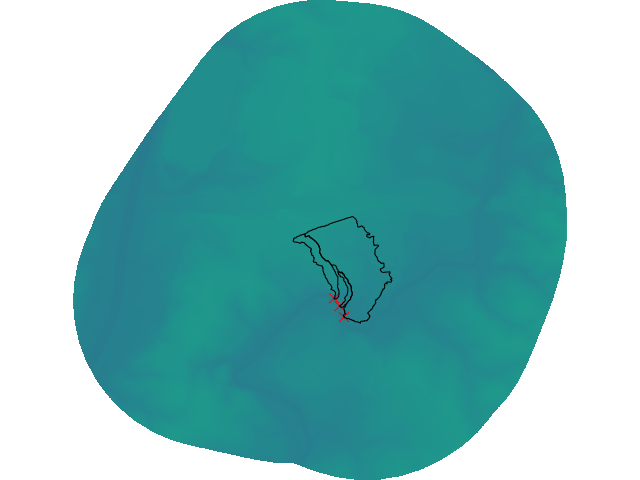

In [33]:
gs.run_command('d.erase')

gs.run_command('d.rast', map=dem)
gs.run_command('d.vect', map= v_outlet,color='red',icon='basic/x',size=10)
gs.run_command('d.vect', map= v_basins,color='black',fill_color='none',type='area')

Image(filename="map.png")

## END